In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam


1. LOAD DATA

In [5]:
df = pd.read_csv("Dataset.csv")

# Fix NaN (updated method)
df['HR'] = df['HR'].ffill()
df['HR'] = df['HR'].bfill()

data = df['HR'].values.reshape(-1, 1)

 2. NORMALIZE

In [6]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

3. CREATE SEQUENCES

In [7]:
def create_dataset(dataset, time_step=10):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 10
X, y = create_dataset(data_scaled, time_step)

4. SPLIT

In [8]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

5. RESHAPE

In [9]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

6. MODEL

In [10]:
model = Sequential([
    Input(shape=(time_step, 1)),
    LSTM(50, return_sequences=True),
    LSTM(50),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

7. TRAIN

In [11]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)


Epoch 1/20
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 0.0044 - val_loss: 0.0030
Epoch 2/20
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch 3/20
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch 4/20
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0032 - val_loss: 0.0030
Epoch 5/20
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0032 - val_loss: 0.0030
Epoch 6/20
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.0032 - val_loss: 0.0032
Epoch 7/20
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 8/20
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.0031 - val_loss: 0.0031
Epoch 9/20
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 10/20
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.0031 - val_loss: 0.0031
Epoch 11/20
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 12/20
1839/18

8. PREDICT

In [12]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

1839/1839 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
460/460 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


9. CHECK NaN

In [13]:
print("NaN in train_pred:", np.isnan(train_pred).sum())
print("NaN in test_pred:", np.isnan(test_pred).sum())

NaN in train_pred: 0
NaN in test_pred: 0


10. EVALUATE

In [14]:
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred))

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 7.7209153366011325
Test RMSE: 7.624710371947502


11. PLOT

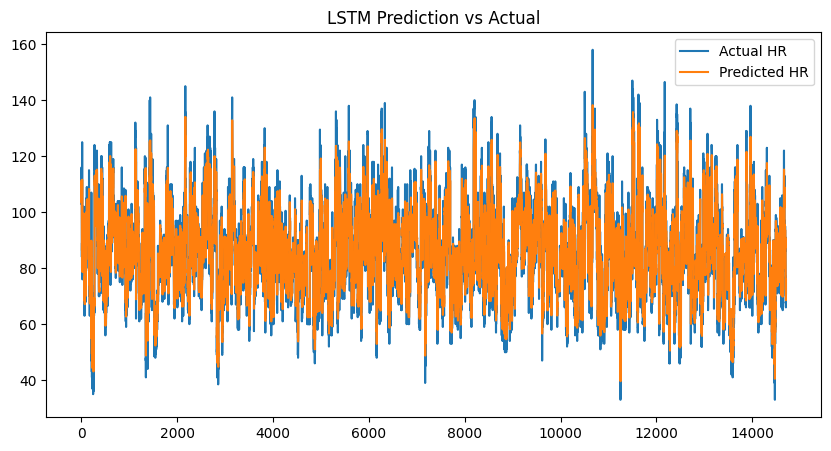

0

In [15]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual HR")
plt.plot(test_pred, label="Predicted HR")
plt.legend()
plt.title("LSTM Prediction vs Actual")
plt.show()
000000000000000000000000000000000000000000000000000